In [1]:
import pandas as pd

customers = pd.read_csv("../data/processed/customers_large.csv")
products = pd.read_csv("../data/processed/products_large.csv")
orders = pd.read_csv("../data/processed/orders_large.csv")
order_items = pd.read_csv("../data/processed/order_items_large.csv")

print(customers.shape)
print(products.shape)
print(orders.shape)
print(order_items.shape)

(1000, 5)
(200, 4)
(5000, 3)
(12000, 5)


In [2]:
customers.head()

,customer_id,customer_name,email,city,signup_date
0,1,Customer_1,customer1@gmail.com,Chennai,2024-01-22
1,2,Customer_2,customer2@gmail.com,Hyderabad,2025-03-31
2,3,Customer_3,customer3@gmail.com,Pune,2024-05-18
3,4,Customer_4,customer4@gmail.com,Pune,2024-02-02
4,5,Customer_5,customer5@gmail.com,Bangalore,2025-01-10


In [3]:
products.head()

,product_id,product_name,category,price
0,1,Product_1,Electronics,21124
1,2,Product_2,Home,15797
2,3,Product_3,Accessories,23713
3,4,Product_4,Electronics,34739
4,5,Product_5,Accessories,17897


In [4]:
order_items["revenue"] = (
    order_items["quantity"] *
    order_items["unit_price"]
)

order_items.head()

,order_item_id,order_id,product_id,quantity,unit_price,revenue
0,1,2389,41,5,46025,230125
1,2,2437,74,4,31216,124864
2,3,373,170,2,6241,12482
3,4,647,52,4,30116,120464
4,5,1913,138,3,16853,50559


In [5]:
total_revenue = order_items["revenue"].sum()

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹1,016,247,934.00


In [6]:
product_revenue = (
    order_items
    .groupby("product_id")["revenue"]
    .sum()
    .reset_index()
)

top_products = (
    product_revenue
    .merge(products, on="product_id")
    .sort_values(
        by="revenue",
        ascending=False
    )
    .head(10)
)

top_products[
    ["product_name", "category", "revenue"]
]

,product_name,category,revenue
65,Product_66,Home,10954032
192,Product_193,Home,10123488
177,Product_178,Home,9846576
178,Product_179,Fashion,9845682
87,Product_88,Accessories,9785370
119,Product_120,Electronics,9705690
144,Product_145,Electronics,9590958
180,Product_181,Home,9442629
182,Product_183,Fashion,9441619
154,Product_155,Fashion,9287460


In [7]:
category_revenue = (
    top_products
)

category_revenue = (
    order_items
    .merge(products, on="product_id")
    .groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Fashion        295257284
Accessories    260115224
Electronics    237756394
Home           223119032
Name: revenue, dtype: int64

In [8]:
customer_revenue = (
    order_items
    .merge(orders, on="order_id")
    .groupby("customer_id")["revenue"]
    .sum()
    .reset_index()
)

top_customers = (
    customer_revenue
    .merge(customers, on="customer_id")
    .sort_values(
        by="revenue",
        ascending=False
    )
    .head(10)
)

top_customers[
    ["customer_name", "city", "revenue"]
]

,customer_name,city,revenue
888,Customer_897,Mumbai,3318433
484,Customer_490,Delhi,3014514
972,Customer_982,Hyderabad,2969792
781,Customer_788,Hyderabad,2949794
398,Customer_403,Bangalore,2795879
432,Customer_438,Pune,2795589
312,Customer_316,Pune,2762717
503,Customer_509,Chennai,2745505
538,Customer_544,Mumbai,2732335
652,Customer_659,Chennai,2595776


In [9]:
city_revenue = (
    customer_revenue
    .merge(customers, on="customer_id")
    .groupby("city")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

city_revenue

city
Mumbai       157878614
Kolkata      157847123
Chennai      155481014
Delhi        151355544
Hyderabad    149478008
Bangalore    125095629
Pune         119112002
Name: revenue, dtype: int64

In [10]:
monthly_revenue = (
    order_items
    .merge(orders, on="order_id")
)

monthly_revenue["order_date"] = pd.to_datetime(
    monthly_revenue["order_date"]
)

monthly_revenue["month"] = (
    monthly_revenue["order_date"]
    .dt.to_period("M")
)

monthly_revenue = (
    monthly_revenue
    .groupby("month")["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,month,revenue
0,2025-01,96785348
1,2025-02,69902671
2,2025-03,81227965
3,2025-04,81172031
4,2025-05,84635425


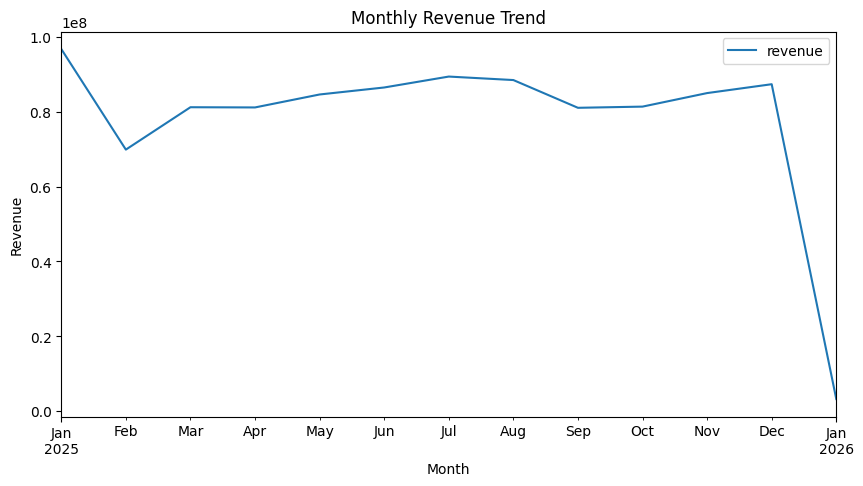

In [11]:
import matplotlib.pyplot as plt

monthly_revenue.plot(
    x="month",
    y="revenue",
    figsize=(10,5)
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [12]:
customer_revenue = (
    order_items
    .merge(orders, on="order_id")
    .groupby("customer_id")["revenue"]
    .sum()
    .reset_index()
)

top_customers = (
    customer_revenue
    .merge(customers, on="customer_id")
    .sort_values(
        by="revenue",
        ascending=False
    )
    .head(10)
)

top_customers[
    ["customer_name", "city", "revenue"]
]

,customer_name,city,revenue
888,Customer_897,Mumbai,3318433
484,Customer_490,Delhi,3014514
972,Customer_982,Hyderabad,2969792
781,Customer_788,Hyderabad,2949794
398,Customer_403,Bangalore,2795879
432,Customer_438,Pune,2795589
312,Customer_316,Pune,2762717
503,Customer_509,Chennai,2745505
538,Customer_544,Mumbai,2732335
652,Customer_659,Chennai,2595776


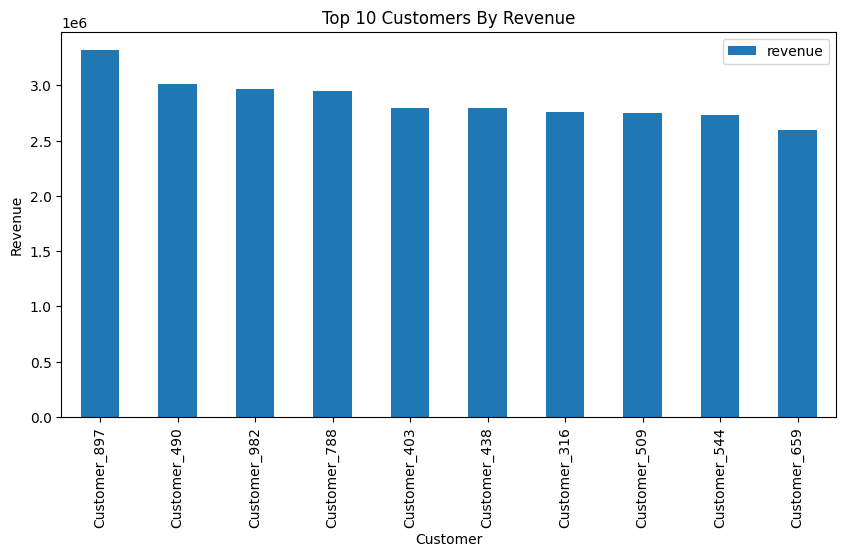

In [13]:
import matplotlib.pyplot as plt

top_customers.plot(
    x="customer_name",
    y="revenue",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers By Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")

plt.show()

In [14]:
city_revenue = (
    customer_revenue
    .merge(customers, on="customer_id")
    .groupby("city")["revenue"]
    .sum()
    .reset_index()
)

city_revenue = city_revenue.sort_values(
    by="revenue",
    ascending=False
)

city_revenue

,city,revenue
5,Mumbai,157878614
4,Kolkata,157847123
1,Chennai,155481014
2,Delhi,151355544
3,Hyderabad,149478008
0,Bangalore,125095629
6,Pune,119112002


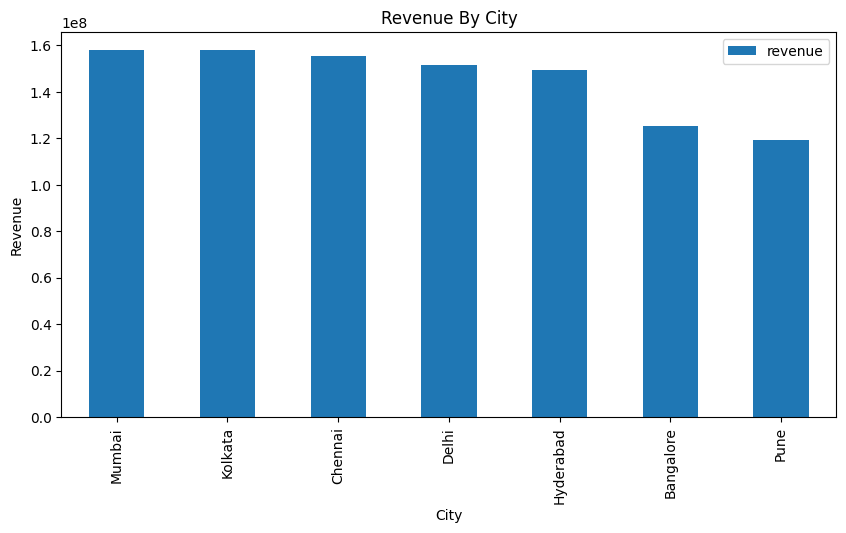

In [15]:
city_revenue.plot(
    x="city",
    y="revenue",
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue By City")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.show()

In [1]:
customer_orders = (
    orders
    .groupby("customer_id")
    .size()
    .reset_index(name="order_count")
)

customer_orders.head()

NameError: name 'orders' is not defined

In [2]:
product_sales = (
    order_items
    .groupby("product_id")["quantity"]
    .sum()
    .reset_index()
)

top_products_qty = (
    product_sales
    .merge(products, on="product_id")
    .sort_values(
        by="quantity",
        ascending=False
    )
    .head(10)
)

top_products_qty[
    ["product_name", "category", "quantity"]
]

NameError: name 'order_items' is not defined

In [3]:
import pandas as pd

customers = pd.read_csv("../data/processed/customers_large.csv")
products = pd.read_csv("../data/processed/products_large.csv")
orders = pd.read_csv("../data/processed/orders_large.csv")
order_items = pd.read_csv("../data/processed/order_items_large.csv")

print("Data Loaded Successfully")

Data Loaded Successfully


In [4]:
customers.shape
products.shape
orders.shape
order_items.shape

(12000, 5)

In [5]:
order_items["revenue"] = (
    order_items["quantity"] *
    order_items["unit_price"]
)

In [7]:
customer_orders = (
    orders
    .groupby("customer_id")
    .size()
    .reset_index(name="order_count")
)

In [8]:
product_sales = (
    order_items
    .groupby("product_id")["quantity"]
    .sum()
    .reset_index()
)

In [9]:
product_revenue = (
    order_items
    .groupby("product_id")["revenue"]
    .sum()
    .reset_index()
)

top_products = (
    product_revenue
    .merge(products, on="product_id")
    .sort_values(
        by="revenue",
        ascending=False
    )
    .head(10)
)

top_products[
    ["product_name", "category", "revenue"]
]

,product_name,category,revenue
65,Product_66,Home,10954032
192,Product_193,Home,10123488
177,Product_178,Home,9846576
178,Product_179,Fashion,9845682
87,Product_88,Accessories,9785370
119,Product_120,Electronics,9705690
144,Product_145,Electronics,9590958
180,Product_181,Home,9442629
182,Product_183,Fashion,9441619
154,Product_155,Fashion,9287460


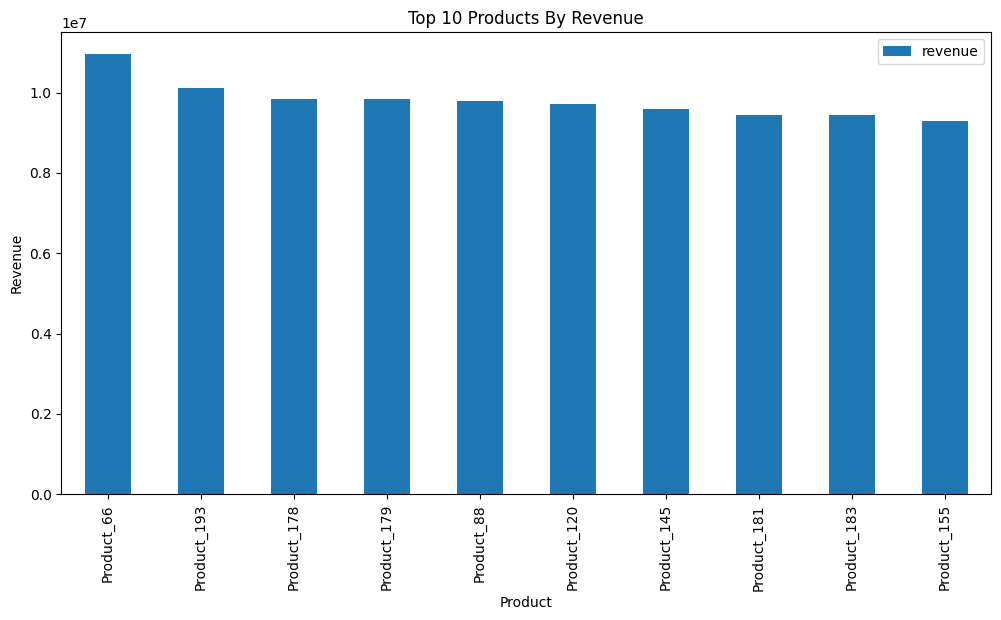

In [10]:
import matplotlib.pyplot as plt

top_products.plot(
    x="product_name",
    y="revenue",
    kind="bar",
    figsize=(12,6)
)

plt.title("Top 10 Products By Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

In [11]:
category_analysis = (
    order_items
    .merge(products, on="product_id")
    .groupby("category")
    .agg({
        "revenue": "sum",
        "quantity": "sum"
    })
    .reset_index()
)

category_analysis

,category,revenue,quantity
0,Accessories,260115224,8865
1,Electronics,237756394,8268
2,Fashion,295257284,10864
3,Home,223119032,7890


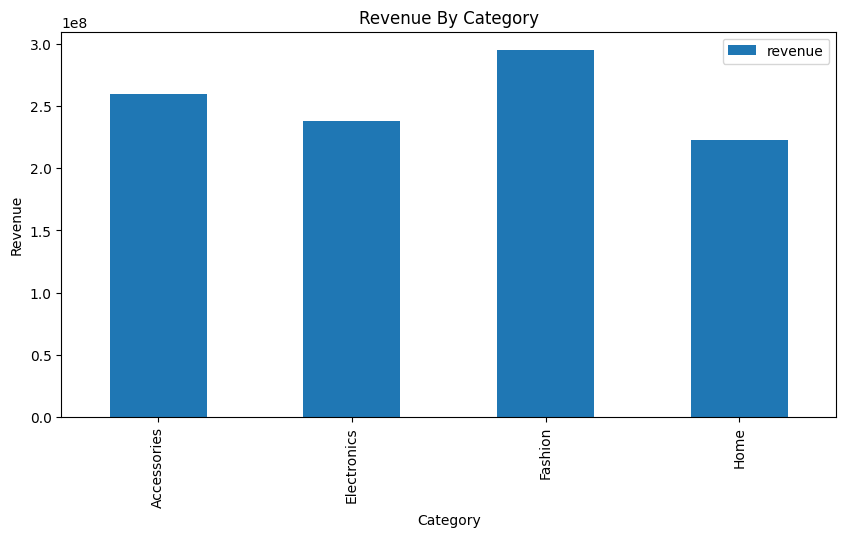

In [12]:
category_analysis.plot(
    x="category",
    y="revenue",
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue By Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [13]:
# Business Insights

## Product Analysis

- Top revenue generating product: __________

## Category Analysis

- Highest revenue category: __________
- Lowest revenue category: __________

## Customer Analysis

- Repeat customer rate: __________ %

## Geographic Analysis

- Highest revenue city: __________

SyntaxError: invalid syntax (605802359.py, line 5)

In [14]:
monthly_revenue = (
    order_items
    .merge(orders, on="order_id")
)

monthly_revenue["order_date"] = pd.to_datetime(
    monthly_revenue["order_date"]
)

monthly_revenue["month"] = (
    monthly_revenue["order_date"]
    .dt.strftime("%Y-%m")
)

monthly_revenue = (
    monthly_revenue
    .groupby("month")["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,month,revenue
0,2025-01,96785348
1,2025-02,69902671
2,2025-03,81227965
3,2025-04,81172031
4,2025-05,84635425
5,2025-06,86506023
6,2025-07,89424126
7,2025-08,88491968
8,2025-09,81076074
9,2025-10,81393100


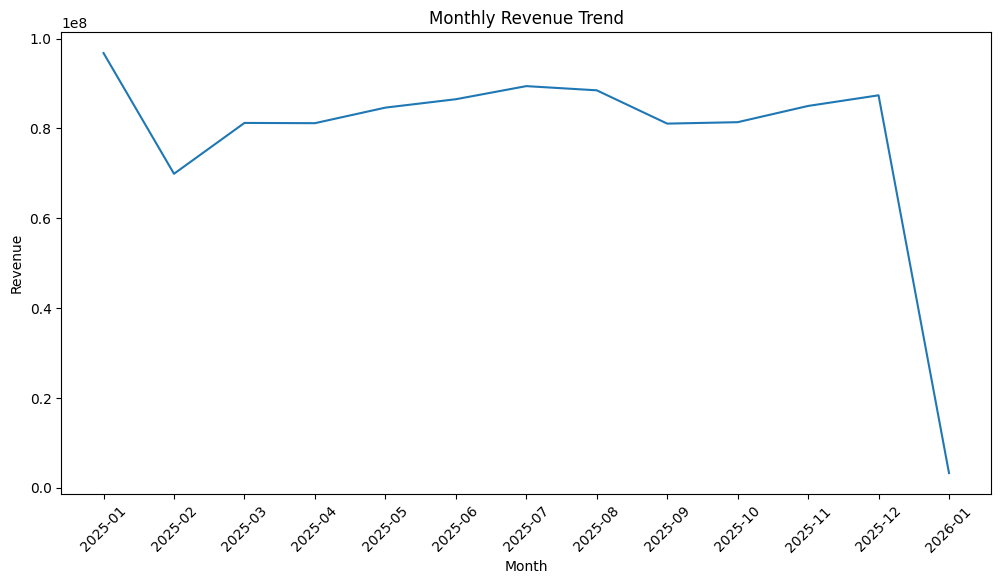

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [16]:
monthly_revenue.sort_values(
    by="revenue",
    ascending=False
).head(1)

,month,revenue
0,2025-01,96785348


In [17]:
# Executive Summary

## Revenue Overview
- Total Revenue: _______

## Customer Insights
- Total Customers: _______
- Repeat Customer Rate: _______

## Product Insights
- Best Selling Product: _______
- Highest Revenue Product: _______

## Category Insights
- Top Category: _______

## Geographic Insights
- Top Revenue City: _______

## Trend Insights
- Best Revenue Month: _______

SyntaxError: invalid syntax (2892028963.py, line 4)